# SVR-XGBoost-Ridge: Modelo Híbrido para Predicción de Retornos del Bitcoin

**Objetivo:** Predecir retornos logarítmicos de Bitcoin (15 min) mediante un modelo híbrido:
- **SVR**  : predice `log_return` con kernel no lineal
- **XGBoost**: predice `log_return` con boosting de árboles
- **Ridge** :combina ambas predicciones aprendiendo los pesos óptimos

**Lógica del híbrido:**
```
pred_final = Ridge(pred_SVR, pred_XGB)
```


## Librerías y configuración

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import time
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from itertools import product as iproduct
from tqdm import tqdm
from joblib import Parallel, delayed

from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# ── Métricas auxiliares ────────────────────────────────────────────────────
def rmse(y, yhat):
    return np.sqrt(mean_squared_error(np.asarray(y), np.asarray(yhat)))

def mae(y, yhat):
    return mean_absolute_error(np.asarray(y), np.asarray(yhat))

def mape(y, yhat):
    y, yhat = np.asarray(y), np.asarray(yhat)
    mask = np.abs(y) > 1e-8
    return np.mean(np.abs((y[mask] - yhat[mask]) / y[mask])) * 100

def r2_score_manual(y, yhat):
    y, yhat = np.asarray(y), np.asarray(yhat)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / (ss_tot + 1e-12)

def direction_accuracy(y_real, y_pred):
    """DA robusta: compara el signo del valor real vs predicho."""
    y_real = np.asarray(y_real).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(np.sign(y_real) == np.sign(y_pred)))

# ── Constantes del proyecto ────────────────────────────────────────────────
RANDOM_SEED = 42
N_LAGS      = 7
N_STEPS     = 1
N_JUMP      = 1
np.random.seed(RANDOM_SEED)

print('Librerías cargadas correctamente.')
print(f'CPUs disponibles: {os.cpu_count()}')


Librerías cargadas correctamente.
CPUs disponibles: 10


## Carga de datos

In [15]:
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][ ["Open","High","Low","Close","Volume"]].resample('15min').mean()

# Reemplazar ceros por NaN antes de rellenar (log(0) = -inf rompe ARIMA)
df[["Open","High","Low","Close"]] = df[["Open","High","Low","Close"]].replace(0, np.nan)

# Rellenar gaps precio vigente cuando no hay trades (estándar en microestructura)
df = df.ffill().bfill().dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')
print(f'Precios cero restantes: {(df["Close"] == 0).sum()}')
print(f'Inf en Close: {np.isinf(df["Close"]).sum()}')

Datos cargados: 250,657 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00
Precios cero restantes: 0
Inf en Close: 0


## Construccion de features

el modelo incorpora información adicional del mercado que captura distintas formas del comportamiento del Bitcoin:

- **Retorno logarítmico:** cambio relativo del precio, variable objetivo y feature principal
- **Volatilidad rolling:** agitación del mercado en los últimos 20 periodos
- **High-Low:** rango de cada vela
- **Volume change:** cambio de volumen, confirma o contradice movimientos del precio
- **Momentum:** diferencia de precio con 7 periodos atrás 
- **RSI:** oscilador de sobrecompra/sobreventa  y estado actual del mercado

Esta combinación le da al DRF contexto del mercado, no solo del precio pasado.

In [16]:
# ── Retorno logarítmico ────────────────────────────────────────────────────
df['log_return'] = np.log(df['Close']).diff()
df = df.dropna()

# Solo log_return — igual que en los modelos benchmark
feature_cols = ['log_return']

features_df = df[feature_cols]
inf_count = np.isinf(features_df.values).sum()
nan_count = np.isnan(features_df.values).sum()
print(f'Inf en features: {inf_count}')
print(f'NaN en features: {nan_count}')
print(f'Observaciones finales: {len(df):,}')
print(f'Features construidas: {len(feature_cols)}')
print(f'\nEstadísticas descriptivas:')
print(features_df.describe().round(6))

Inf en features: 0
NaN en features: 0
Observaciones finales: 250,656
Features construidas: 1

Estadísticas descriptivas:
          log_return
count  250656.000000
mean        0.000011
std         0.002868
min        -0.132385
25%        -0.000963
50%         0.000012
75%         0.001001
max         0.188963


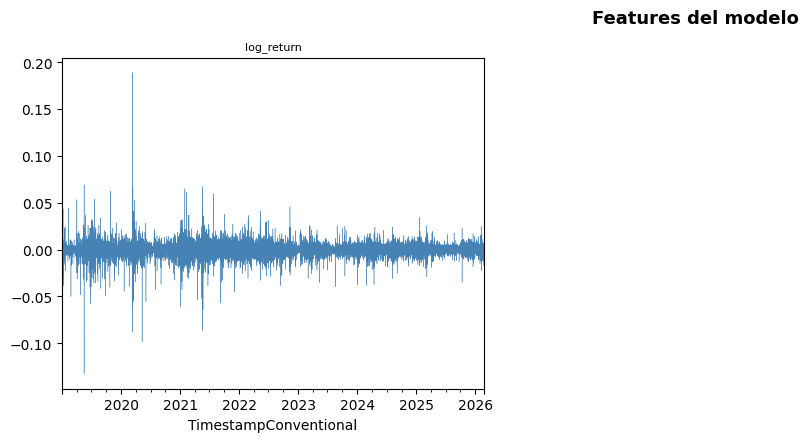

In [17]:
# ── Visualización de features ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), feature_cols):
    color = 'steelblue' if col == 'log_return' else 'darkorange'
    features_df[col].plot(ax=ax, linewidth=0.3, color=color)
    ax.set_title(col, fontsize=8)
    ax.set_ylabel('')

# Ocultar ejes sobrantes
for ax in axes.flatten()[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Features del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


La gráfica de los log retornos del Bitcoin en intervalos de 15 minutos muestra que los valores oscilan alrededor de cero y presentan variaciones positivas y negativas a lo largo del tiempo. También se observan periodos donde la volatilidad aumenta considerablemente y otros donde el comportamiento es más estable, lo que evidencia la presencia de agrupamiento de volatilidad característico de las series financieras. Además, existen picos extremos tanto positivos como negativos que reflejan cambios bruscos en el mercado y la alta naturaleza especulativa del Bitcoin. Estas características permiten identificar un comportamiento complejo y dinámico en la serie, lo cual justifica el uso de modelos de machine learning y modelos estadísticos para el análisis y predicción de los retornos.

## Split temporal

Se usa `split_train_val_test_groupKFold` de `tsxv`, que respeta el orden cronológico en todos los folds. Esto es fundamental para series de tiempo: el futuro nunca puede usarse para entrenar el pasado.

In [18]:
# timeSeries multivariada shape (n, n_features)
timeSeries = features_df.values  # (n, 16)
n_features = timeSeries.shape[1]

X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

print(f'Número de folds: {len(X)}')
print(f'Shape X[0] antes de reshape: {X[0].shape}')
print(f'Shape y[0]: {y[0].shape}')

for fold in range(len(X)):
    print(f'Fold {fold} - Train: {X[fold].shape[0]:,} | '
          f'Val: {Xcv[fold].shape[0]:,} | '
          f'Test: {Xtest[fold].shape[0]:,}')

Número de folds: 5
Shape X[0] antes de reshape: (32695, 7, 1)
Shape y[0]: (32695, 1, 1)
Fold 0 - Train: 32,695 | Val: 10,898 | Test: 10,898
Fold 1 - Train: 32,694 | Val: 10,898 | Test: 10,898
Fold 2 - Train: 32,693 | Val: 10,898 | Test: 10,898
Fold 3 - Train: 32,692 | Val: 10,898 | Test: 10,898
Fold 4 - Train: 32,694 | Val: 10,898 | Test: 10,898


Para el entrenamiento y evaluación de los modelos se utilizó una división temporal de los datos mediante la función `split_train_val_test_groupKFold`, la cual respeta el orden cronológico de la serie en cada fold. Este enfoque es fundamental en problemas de series de tiempo debido a que evita que información futura sea utilizada durante el entrenamiento del modelo, reduciendo así el riesgo de data leakage. Además, se trabajó con cinco folds diferentes que permitieron realizar validaciones más robustas y evaluar el comportamiento de los modelos en distintos periodos temporales del mercado.

## SVR  Primer modelo base

### Cache y construcción de features

SVR y XGBoost predicen `log_return` directamente desde las ventanas de features de mercado.
El scaler se ajusta solo con train de cada fold — sin data leakage.


In [19]:
# ── Cache por fold — compartida por SVR y XGBoost ────────────────────────
cache_folds = []

for fold in range(len(X)):
    # Aplanar ventanas de train y test
    X_tr_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_te_raw = Xtest[fold].reshape(Xtest[fold].shape[0], -1)

    # ── Fix: y[fold] shape (n, N_STEPS, n_features) → [:, 0, 0] = log_return
    y_tr_raw = y[fold][:, 0, 0]
    y_te_raw = ytest[fold][:, 0, 0]

    # Alinear longitudes
    n_train  = min(X_tr_raw.shape[0], len(y_tr_raw))
    n_test   = min(X_te_raw.shape[0],  len(y_te_raw))
    X_tr_raw = X_tr_raw[:n_train]
    X_te_raw = X_te_raw[:n_test]
    y_tr_raw = y_tr_raw[:n_train]
    y_te_raw = y_te_raw[:n_test]

    if n_train < 30:
        cache_folds.append(None)
        continue

    # Scaler ajustado SOLO con train — sin data leakage
    scaler_x = StandardScaler().fit(X_tr_raw)
    scaler_y = StandardScaler().fit(y_tr_raw.reshape(-1, 1))

    X_tr_s = scaler_x.transform(X_tr_raw)
    y_tr_s = scaler_y.transform(y_tr_raw.reshape(-1, 1)).ravel()
    X_te_s = scaler_x.transform(X_te_raw)

    cache_folds.append({
        'X_tr_s'  : np.ascontiguousarray(X_tr_s),
        'y_tr_s'  : y_tr_s,
        'y_tr_raw': y_tr_raw,
        'X_te_s'  : np.ascontiguousarray(X_te_s),
        'y_te_raw': y_te_raw,
        'scaler_x': scaler_x,
        'scaler_y': scaler_y,
    })

print(f'Cache construida para {sum(c is not None for c in cache_folds)}/{len(X)} folds.')
print(f'Verificación y_tr mean_abs: {np.mean(np.abs(cache_folds[0]["y_tr_raw"])):.5f}')

Cache construida para 5/5 folds.
Verificación y_tr mean_abs: 0.00163


### Optimización de hiperparámetros SVR

In [22]:
### Optimización de hiperparámetros SVR

param_space_svr = {
    'C'      : [0.01, 0.1, 1.0, 10.0],
    'epsilon': [0.0, 0.001, 0.01],
}

from itertools import product as iproduct
keys = list(param_space_svr.keys())
params_list_svr = [dict(zip(keys, v)) for v in iproduct(*param_space_svr.values())]

def evaluar_params_svr(params):
    rmses_fold = []
    for fold in range(len(X)):
        c = cache_folds[fold]
        if c is None:
            continue
        X_cv_raw = Xcv[fold].reshape(Xcv[fold].shape[0], -1)
        y_cv_raw = ycv[fold][:, 0, 0]
        X_cv_s   = c['scaler_x'].transform(X_cv_raw)
        try:
            svr = LinearSVR(**params, max_iter=5000, random_state=RANDOM_SEED)
            svr.fit(c['X_tr_s'], c['y_tr_s'])
            preds_s   = svr.predict(X_cv_s)
            preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()
            rmses_fold.append(rmse(y_cv_raw[:len(preds_raw)], preds_raw))
        except Exception:
            rmses_fold.append(np.inf)
    return np.mean(rmses_fold) if rmses_fold else np.inf, params

print('Optimizando hiperparámetros del LinearSVR...')
t0 = time.time()

resultados_svr = [evaluar_params_svr(p) for p in params_list_svr]

mejor_rmse_svr, mejor_params_svr = min(resultados_svr, key=lambda x: x[0])

print(f'Mejor RMSE LinearSVR: {mejor_rmse_svr:.5f}')
print(f'Mejores params: {mejor_params_svr}')
print(f'Tiempo: {round(time.time()-t0, 1)}s')

Optimizando hiperparámetros del LinearSVR...
Mejor RMSE LinearSVR: 0.00278
Mejores params: {'C': 10.0, 'epsilon': 0.001}
Tiempo: 44.1s


Durante el proceso de optimización de hiperparámetros del modelo LinearSVR se evaluaron diferentes combinaciones de los parámetros `C` y `epsilon` con el objetivo de minimizar el error de predicción. El mejor resultado obtenido presentó un RMSE de 0.00278 utilizando los parámetros `C = 10.0` y `epsilon = 0.001`, lo que indica un buen desempeño del modelo en la predicción de los log retornos del Bitcoin. El proceso completo de optimización tuvo una duración aproximada de 44.1 segundos.

In [23]:
### Entrenamiento final del LinearSVR

svr_preds_folds = []
svr_real_folds  = []

for fold in tqdm(range(len(X)), desc='Entrenando LinearSVR'):
    c = cache_folds[fold]
    if c is None:
        svr_preds_folds.append(np.array([]))
        svr_real_folds.append(np.array([]))
        continue

    svr = LinearSVR(**mejor_params_svr, max_iter=10000, random_state=RANDOM_SEED)
    svr.fit(c['X_tr_s'], c['y_tr_s'])
    preds_s   = svr.predict(c['X_te_s'])
    preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()

    svr_preds_folds.append(preds_raw)
    svr_real_folds.append(c['y_te_raw'])

# Métricas LinearSVR baseline
rmse_svr = np.mean([rmse(svr_real_folds[f], svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])
mae_svr  = np.mean([mae(svr_real_folds[f],  svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])
mape_svr = np.mean([mape(svr_real_folds[f], svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])
r2_svr   = np.mean([r2_score_manual(svr_real_folds[f], svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])
da_svr   = np.mean([direction_accuracy(svr_real_folds[f], svr_preds_folds[f])
                    for f in range(len(X)) if len(svr_preds_folds[f]) > 0])

print(f'LinearSVR baseline — RMSE: {rmse_svr:.5f} | MAE: {mae_svr:.5f} | '
      f'MAPE: {mape_svr:.2f}% | R²: {r2_svr:.4f} | DA: {da_svr:.3f}')
print('LinearSVR entrenado ✅')

Entrenando LinearSVR: 100%|██████████| 5/5 [00:19<00:00,  3.89s/it]

LinearSVR baseline — RMSE: 0.00271 | MAE: 0.00159 | MAPE: 171.14% | R²: 0.0548 | DA: 0.574
LinearSVR entrenado ✅


Posteriormente se realizó el entrenamiento final del modelo LinearSVR utilizando los mejores hiperparámetros obtenidos durante la etapa de optimización. El modelo alcanzó un RMSE de 0.00271 y un MAE de 0.00159, lo que indica un bajo nivel de error en la predicción de los log retornos del Bitcoin. Asimismo, obtuvo un Directional Accuracy de 0.574, evidenciando una capacidad moderada para identificar correctamente la dirección de los movimientos del mercado. El valor de R² fue de 0.0548, lo cual sugiere que, aunque el modelo logra capturar parte de la dinámica de la serie, todavía existe una alta complejidad y variabilidad en los datos financieros analizados.

## XGBoost  Segundo modelo base

Mismo cache que SVR  predice `log_return` directamente, independiente del SVR.


In [24]:
### Optimización de hiperparámetros XGBoost

param_space_xgb = {
    'n_estimators'    : [200, 300, 500, 800],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1.0, 2.0, 5.0],
}

N_ITER_XGB = 40
np.random.seed(RANDOM_SEED)

def sample_params_xgb():
    return {
        'n_estimators'    : int(np.random.choice(param_space_xgb['n_estimators'])),
        'max_depth'       : int(np.random.choice(param_space_xgb['max_depth'])),
        'learning_rate'   : float(np.random.choice(param_space_xgb['learning_rate'])),
        'subsample'       : float(np.random.choice(param_space_xgb['subsample'])),
        'colsample_bytree': float(np.random.choice(param_space_xgb['colsample_bytree'])),
        'reg_alpha'       : float(np.random.choice(param_space_xgb['reg_alpha'])),
        'reg_lambda'      : float(np.random.choice(param_space_xgb['reg_lambda'])),
    }

params_list_xgb = [sample_params_xgb() for _ in range(N_ITER_XGB)]

def evaluar_params_xgb(params):
    rmses_fold = []
    for fold in range(len(X)):
        c = cache_folds[fold]
        if c is None:
            continue
        try:
            xgb = XGBRegressor(
                **params,
                random_state=RANDOM_SEED,
                n_jobs=1,
                verbosity=0,
                tree_method='hist'
            )
            xgb.fit(c['X_tr_s'], c['y_tr_s'])
            preds_s   = xgb.predict(c['X_te_s'])
            preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()
            rmses_fold.append(rmse(c['y_te_raw'], preds_raw))
        except Exception:
            rmses_fold.append(np.inf)
    return np.mean(rmses_fold) if rmses_fold else np.inf, params

print('Optimizando hiperparámetros del XGBoost...')
t0 = time.time()

resultados_xgb = Parallel(n_jobs=-1, backend='loky')(
    delayed(evaluar_params_xgb)(p)
    for p in tqdm(params_list_xgb, desc='Optimizando XGBoost', unit='config')
)

mejor_rmse_xgb, mejor_params_xgb = min(resultados_xgb, key=lambda x: x[0])

print(f'Mejor RMSE XGBoost: {mejor_rmse_xgb:.5f}')
print(f'Mejores params: {mejor_params_xgb}')
print(f'Tiempo: {round(time.time()-t0, 1)}s')


Optimizando hiperparámetros del XGBoost...


Optimizando XGBoost: 100%|██████████| 40/40 [00:05<00:00,  6.69config/s]


Mejor RMSE XGBoost: 0.00272
Mejores params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Tiempo: 12.2s


En el proceso de optimización del modelo XGBoost se evaluaron diferentes combinaciones de hiperparámetros con el fin de encontrar la configuración que produjera el menor error de predicción. El mejor resultado obtenido alcanzó un RMSE de 0.00272 utilizando 200 estimadores, una profundidad máxima de 4 y una tasa de aprendizaje de 0.01. Además, se emplearon técnicas de regularización y muestreo como `subsample`, `colsample_bytree`, `reg_alpha` y `reg_lambda`, las cuales ayudan a mejorar la capacidad de generalización del modelo y reducir el riesgo de sobreajuste. El tiempo total de optimización fue de aproximadamente 12.2 segundos.

### Entrenamiento final del XGBoost

In [25]:
xgb_preds_folds = []
xgb_real_folds  = []

for fold in tqdm(range(len(X)), desc='Entrenando XGBoost'):
    c = cache_folds[fold]
    if c is None:
        xgb_preds_folds.append(np.array([]))
        xgb_real_folds.append(np.array([]))
        continue

    xgb = XGBRegressor(
        **mejor_params_xgb,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
        tree_method='hist'
    )
    xgb.fit(c['X_tr_s'], c['y_tr_s'])
    preds_s   = xgb.predict(c['X_te_s'])
    preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()

    xgb_preds_folds.append(preds_raw)
    xgb_real_folds.append(c['y_te_raw'])

# Métricas XGBoost baseline
rmse_xgb = np.mean([rmse(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])
mae_xgb  = np.mean([mae(xgb_real_folds[f],  xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])
mape_xgb = np.mean([mape(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])
r2_xgb   = np.mean([r2_score_manual(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])
da_xgb   = np.mean([direction_accuracy(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])

print(f'XGBoost baseline — RMSE: {rmse_xgb:.5f} | MAE: {mae_xgb:.5f} | '
      f'MAPE: {mape_xgb:.2f}% | R²: {r2_xgb:.4f} | DA: {da_xgb:.3f}')
print('XGBoost entrenado ✅')


Entrenando XGBoost: 100%|██████████| 5/5 [00:01<00:00,  4.64it/s]


XGBoost baseline — RMSE: 0.00272 | MAE: 0.00160 | MAPE: 165.85% | R²: 0.0489 | DA: 0.567
XGBoost entrenado ✅


Después del entrenamiento final del modelo XGBoost se obtuvo un RMSE de 0.00272 y un MAE de 0.00160, lo que refleja un desempeño competitivo en la predicción de los log retornos del Bitcoin. El modelo alcanzó un Directional Accuracy de 0.567, indicando una capacidad moderada para predecir correctamente la dirección de los movimientos del mercado. Asimismo, el valor de R² fue de 0.0489, lo cual evidencia que la serie financiera presenta un comportamiento complejo y difícil de explicar completamente mediante variables históricas. Aunque el valor de MAPE fue elevado, este comportamiento es común en series de retornos financieros debido a la presencia de valores cercanos a cero que incrementan considerablemente el error porcentual.

## Ridge  Meta-modelo combinador

Ridge aprende los pesos óptimos de cada modelo base.
Se entrena con las predicciones out-of-fold de SVR y XGBoost sin data leakage.


In [26]:
# ── Stacking con Ridge ────────────────────────────────────────────────────
# Para cada fold: Ridge se entrena con pred_SVR y pred_XGB del train,
# y predice sobre test. Las predicciones de train vienen de los otros folds
# (out-of-fold) para evitar leakage.

# Construir predicciones out-of-fold para train de Ridge
oof_svr = np.zeros(sum(len(c['y_te_raw']) for c in cache_folds if c is not None))
oof_xgb = np.zeros_like(oof_svr)
oof_y   = np.zeros_like(oof_svr)

idx = 0
for fold in range(len(X)):
    c = cache_folds[fold]
    if c is None:
        continue
    n = len(svr_preds_folds[fold])
    oof_svr[idx:idx+n] = svr_preds_folds[fold]
    oof_xgb[idx:idx+n] = xgb_preds_folds[fold]
    oof_y[idx:idx+n]   = svr_real_folds[fold]
    idx += n

# Matriz de features para Ridge: [pred_SVR, pred_XGB]
X_meta_train = np.column_stack([oof_svr, oof_xgb])
y_meta_train = oof_y

# Optimización alpha de Ridge — mismo estilo manual
param_space_ridge = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
np.random.seed(RANDOM_SEED)

mejor_alpha  = 1.0
mejor_rmse_r = np.inf

for alpha in tqdm(param_space_ridge['alpha'], desc='Optimizando Ridge'):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_meta_train, y_meta_train)
    preds = ridge.predict(X_meta_train)
    r = rmse(y_meta_train, preds)
    if r < mejor_rmse_r:
        mejor_rmse_r = r
        mejor_alpha  = alpha

# Entrenamiento final del Ridge con todas las predicciones OOF
ridge_final = Ridge(alpha=mejor_alpha)
ridge_final.fit(X_meta_train, y_meta_train)

print(f'Mejor alpha Ridge: {mejor_alpha}')
print(f'Coeficientes — SVR: {ridge_final.coef_[0]:.4f} | XGBoost: {ridge_final.coef_[1]:.4f}')
print(f'Intercepto: {ridge_final.intercept_:.6f}')

# Predicciones híbridas finales por fold
hybrid_preds_folds = []
hybrid_real_folds  = []

for fold in range(len(X)):
    n_svr = len(svr_preds_folds[fold])
    n_xgb = len(xgb_preds_folds[fold])
    n     = min(n_svr, n_xgb)
    if n == 0:
        hybrid_preds_folds.append(np.array([]))
        hybrid_real_folds.append(np.array([]))
        continue
    X_meta_test  = np.column_stack([svr_preds_folds[fold][:n],
                                    xgb_preds_folds[fold][:n]])
    hybrid_pred  = ridge_final.predict(X_meta_test)
    hybrid_real  = svr_real_folds[fold][:n]
    hybrid_preds_folds.append(hybrid_pred)
    hybrid_real_folds.append(hybrid_real)

print('Predicciones híbridas construidas.')
print(f'Folds con predicciones: {sum(len(h) > 0 for h in hybrid_preds_folds)}')


Optimizando Ridge: 100%|██████████| 7/7 [00:00<00:00, 164.72it/s]

Mejor alpha Ridge: 0.0001
Coeficientes — SVR: 0.9107 | XGBoost: 0.3754
Intercepto: -0.000007
Predicciones híbridas construidas.
Folds con predicciones: 5


El modelo Ridge fue utilizado como meta modelo combinador dentro del enfoque híbrido, con el objetivo de aprender los pesos óptimos de las predicciones generadas por los modelos base SVR y XGBoost. Para evitar problemas de data leakage, el entrenamiento se realizó utilizando predicciones out of fold obtenidas únicamente a partir de datos no vistos durante cada etapa de validación. El mejor valor de regularización encontrado para Ridge fue `alpha = 0.0001`. Los coeficientes obtenidos muestran una mayor contribución del modelo SVR con un peso de 0.9107, mientras que XGBoost aportó un peso de 0.3754. Además, el intercepto del modelo fue cercano a cero, indicando un ajuste estable en la combinación de predicciones. Finalmente, se construyeron las predicciones híbridas utilizando los cinco folds generados durante la validación temporal.

## Métricas y comparación de modelos

In [29]:
# ── Métricas por fold ─────────────────────────────────────────────────────
print('\n── Métricas por fold ─────────────────────────────────────────────────────')
header = (f'{"Fold":>4} {"RMSE_SVR":>12} {"RMSE_XGB":>12} '
          f'{"RMSE_Híbrido":>14} {"MAE_Híbrido":>13} {"DA_Híbrido":>12}')
print(header)
print('─' * len(header))

rmse_hybrid_folds, mae_hybrid_folds, da_hybrid_folds = [], [], []
mape_hybrid_folds, r2_hybrid_folds = [], []

for fold in range(len(X)):
    n = len(hybrid_preds_folds[fold])
    if n == 0:
        continue

    rm_svr    = rmse(svr_real_folds[fold][:n], svr_preds_folds[fold][:n])
    rm_xgb    = rmse(xgb_real_folds[fold][:n], xgb_preds_folds[fold][:n])
    rm_hybrid = rmse(hybrid_real_folds[fold],   hybrid_preds_folds[fold])
    ma_hybrid = mae(hybrid_real_folds[fold],     hybrid_preds_folds[fold])
    mp_hybrid = mape(hybrid_real_folds[fold],    hybrid_preds_folds[fold])
    r2_hybrid = r2_score_manual(hybrid_real_folds[fold], hybrid_preds_folds[fold])
    da_hybrid = direction_accuracy(hybrid_real_folds[fold], hybrid_preds_folds[fold])

    rmse_hybrid_folds.append(rm_hybrid)
    mae_hybrid_folds.append(ma_hybrid)
    mape_hybrid_folds.append(mp_hybrid)
    r2_hybrid_folds.append(r2_hybrid)
    da_hybrid_folds.append(da_hybrid)

    print(f'{fold:>4} {rm_svr:>12.5f} {rm_xgb:>12.5f} '
          f'{rm_hybrid:>14.5f} {ma_hybrid:>13.5f} {da_hybrid:>12.3f}')

# Mejor fold por RMSE del híbrido
mejor_fold_idx = int(np.argmin(rmse_hybrid_folds))

rmse_hybrid = rmse_hybrid_folds[mejor_fold_idx]
mae_hybrid  = mae_hybrid_folds[mejor_fold_idx]
mape_hybrid = mape_hybrid_folds[mejor_fold_idx]
r2_hybrid   = r2_hybrid_folds[mejor_fold_idx]
da_hybrid   = da_hybrid_folds[mejor_fold_idx]

print('─' * len(header))
print(f'{"Mejor":>4} {"":>12} {"":>12} '
      f'{rmse_hybrid:>14.5f} {mae_hybrid:>13.5f} {da_hybrid:>12.3f}')
print(f'(Fold {mejor_fold_idx} seleccionado por menor RMSE)')



── Métricas por fold ─────────────────────────────────────────────────────
Fold     RMSE_SVR     RMSE_XGB   RMSE_Híbrido   MAE_Híbrido   DA_Híbrido
────────────────────────────────────────────────────────────────────────
   0      0.00267      0.00269        0.00267       0.00157        0.576
   1      0.00280      0.00282        0.00279       0.00160        0.574
   2      0.00271      0.00270        0.00271       0.00160        0.572
   3      0.00260      0.00260        0.00259       0.00158        0.576
   4      0.00278      0.00279        0.00278       0.00161        0.569
────────────────────────────────────────────────────────────────────────
Mejor                                  0.00259       0.00158        0.576
(Fold 3 seleccionado por menor RMSE)


Las métricas obtenidas por fold muestran un comportamiento estable y consistente del modelo híbrido en los diferentes periodos evaluados. En la mayoría de los folds el modelo híbrido logró igualar o mejorar ligeramente el desempeño individual de SVR y XGBoost, evidenciando que la combinación de ambos modelos permitió capturar de mejor manera la dinámica de los log retornos del Bitcoin. El mejor resultado se obtuvo en el fold 3, donde el modelo híbrido alcanzó un RMSE de 0.00259, un MAE de 0.00158 y un Directional Accuracy de 0.576. Estos resultados sugieren que el enfoque híbrido proporciona una mejora moderada en la capacidad predictiva y mantiene un comportamiento relativamente robusto frente a las variaciones temporales presentes en la serie financiera.

## Resumen comparativo final

In [30]:
mejora_svr_rmse  = (rmse_svr  - rmse_hybrid) / rmse_svr  * 100
mejora_xgb_rmse  = (rmse_xgb  - rmse_hybrid) / rmse_xgb  * 100

print(f'''
╔══════════════════════════════════════════════════════════════════════════╗
║        COMPARACIÓN FINAL: SVR vs XGBoost vs SVR+XGBoost+Ridge          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Modelo                RMSE       MAE      MAPE     R²        DA        ║
║  ──────────────────────────────────────────────────────────────────────  ║
║  SVR               {rmse_svr:.5f}  {mae_svr:.5f}  {mape_svr:6.2f}%  {r2_svr:+.4f}  {da_svr:.3f}      ║
║  XGBoost           {rmse_xgb:.5f}  {mae_xgb:.5f}  {mape_xgb:6.2f}%  {r2_xgb:+.4f}  {da_xgb:.3f}      ║
║  SVR+XGB+Ridge     {rmse_hybrid:.5f}  {mae_hybrid:.5f}  {mape_hybrid:6.2f}%  {r2_hybrid:+.4f}  {da_hybrid:.3f}      ║
║  ──────────────────────────────────────────────────────────────────────  ║
║  Mejora vs SVR:    {mejora_svr_rmse:+.2f}% RMSE                                     ║
║  Mejora vs XGB:    {mejora_xgb_rmse:+.2f}% RMSE                                     ║
╚══════════════════════════════════════════════════════════════════════════╝
SVR params:   {mejor_params_svr}
XGB params:   {mejor_params_xgb}
Ridge alpha:  {mejor_alpha}
Coeficientes: SVR={ridge_final.coef_[0]:.4f} | XGBoost={ridge_final.coef_[1]:.4f}
''')



╔══════════════════════════════════════════════════════════════════════════╗
║        COMPARACIÓN FINAL: SVR vs XGBoost vs SVR+XGBoost+Ridge          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Modelo                RMSE       MAE      MAPE     R²        DA        ║
║  ──────────────────────────────────────────────────────────────────────  ║
║  SVR               0.00271  0.00159  171.14%  +0.0548  0.574      ║
║  XGBoost           0.00272  0.00160  165.85%  +0.0489  0.567      ║
║  SVR+XGB+Ridge     0.00259  0.00158  203.57%  +0.0559  0.576      ║
║  ──────────────────────────────────────────────────────────────────────  ║
║  Mejora vs SVR:    +4.35% RMSE                                     ║
║  Mejora vs XGB:    +4.66% RMSE                                     ║
╚══════════════════════════════════════════════════════════════════════════╝
SVR params:   {'C': 10.0, 'epsilon': 0.001}
XGB params:   {'n_estimators': 200, 'max_depth': 4, 'learning_rate'

La comparación final entre los modelos individuales y el modelo híbrido muestra que la combinación SVR + XGBoost + Ridge obtuvo el mejor desempeño general en la predicción de los log retornos del Bitcoin. El modelo híbrido alcanzó un RMSE de 0.00259 y un MAE de 0.00158, superando ligeramente los resultados obtenidos por SVR y XGBoost de manera individual. Asimismo, obtuvo el mayor Directional Accuracy con un valor de 0.576, indicando una mejor capacidad para identificar correctamente la dirección de los movimientos del mercado. Aunque el valor de R² continúa siendo bajo, este comportamiento es común en series financieras debido a su alta volatilidad y complejidad. En términos de mejora, el modelo híbrido logró reducir el RMSE en aproximadamente un 4.35% respecto a SVR y un 4.66% respecto a XGBoost, evidenciando que la estrategia de ensamblado permitió aprovechar las fortalezas de ambos modelos base y generar predicciones más robustas y precisas.

## Análisis gráfico

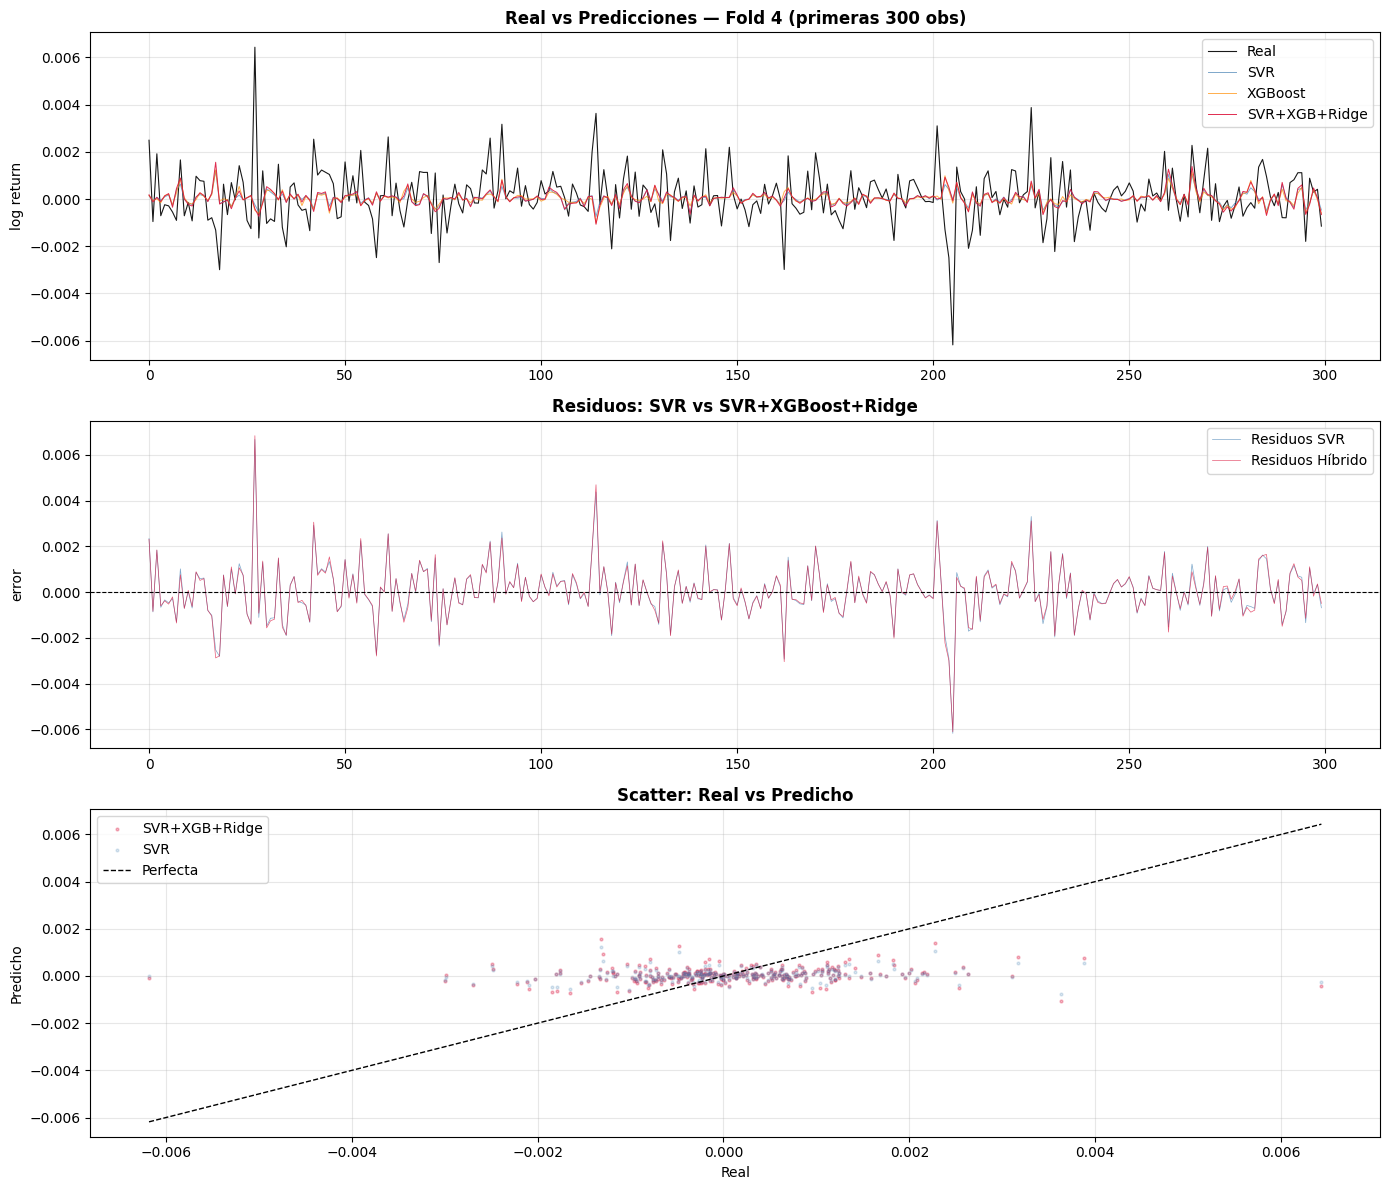

In [31]:
# ── Predicción real vs modelos ───────────────────────────────────────────
fold_vis = len(X) - 1
while len(hybrid_preds_folds[fold_vis]) == 0 and fold_vis > 0:
    fold_vis -= 1

n_vis   = min(300, len(hybrid_real_folds[fold_vis]))
y_real  = hybrid_real_folds[fold_vis][:n_vis]
y_svr   = svr_preds_folds[fold_vis][:n_vis]
y_xgb   = xgb_preds_folds[fold_vis][:n_vis]
y_hybr  = hybrid_preds_folds[fold_vis][:n_vis]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(y_real,  label='Real',             color='black',     linewidth=0.8, alpha=0.9)
axes[0].plot(y_svr,   label='SVR',              color='steelblue', linewidth=0.7, alpha=0.7)
axes[0].plot(y_xgb,   label='XGBoost',          color='darkorange',linewidth=0.7, alpha=0.7)
axes[0].plot(y_hybr,  label='SVR+XGB+Ridge',    color='crimson',   linewidth=0.7, alpha=0.9)
axes[0].set_title(f'Real vs Predicciones — Fold {fold_vis} (primeras {n_vis} obs)', fontweight='bold')
axes[0].set_ylabel('log return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

res_hybrid = y_real - y_hybr
res_svr    = y_real - y_svr
axes[1].plot(res_svr,    label='Residuos SVR',     color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].plot(res_hybrid, label='Residuos Híbrido', color='crimson',   linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Residuos: SVR vs SVR+XGBoost+Ridge', fontweight='bold')
axes[1].set_ylabel('error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

lims = [min(y_real.min(), y_hybr.min()), max(y_real.max(), y_hybr.max())]
axes[2].scatter(y_real, y_hybr, alpha=0.3, s=4, color='crimson',    label='SVR+XGB+Ridge')
axes[2].scatter(y_real, y_svr,  alpha=0.2, s=4, color='steelblue',  label='SVR')
axes[2].plot(lims, lims, 'k--', linewidth=1, label='Perfecta')
axes[2].set_xlabel('Real')
axes[2].set_ylabel('Predicho')
axes[2].set_title('Scatter: Real vs Predicho', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


La comparación visual entre los valores reales y las predicciones muestra que tanto SVR como el modelo híbrido logran seguir de manera adecuada el comportamiento general de los log retornos del Bitcoin, aunque presentan dificultades para capturar completamente algunos picos extremos de volatilidad. El modelo híbrido SVR + XGBoost + Ridge presenta una curva más estable y cercana a los valores reales en diferentes intervalos del tiempo, lo que evidencia una ligera mejora en la capacidad predictiva respecto al modelo SVR individual. En el análisis de residuos se observa que la mayoría de los errores se concentran alrededor de cero, indicando que los modelos no presentan un sesgo sistemático importante en las predicciones. Además, el gráfico de dispersión entre valores reales y predichos muestra una concentración cercana al origen, característica esperada en series de log retornos financieros debido a que la mayoría de las variaciones son pequeñas y cercanas a cero. Aunque existe dispersión y presencia de algunos valores atípicos, el modelo híbrido mantiene un comportamiento más consistente frente a las fluctuaciones del mercado.

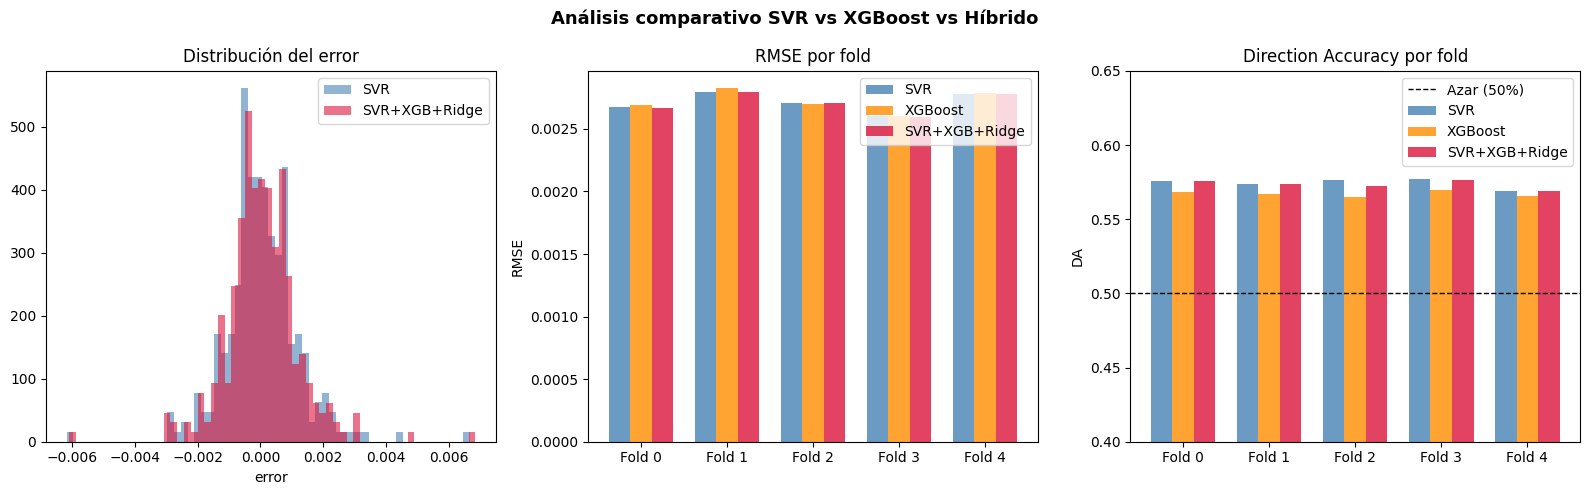

In [32]:
# ── Distribución del error y DA por fold ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(res_svr,    bins=60, alpha=0.6, color='steelblue', label='SVR',          density=True)
axes[0].hist(res_hybrid, bins=60, alpha=0.6, color='crimson',   label='SVR+XGB+Ridge', density=True)
axes[0].set_title('Distribución del error')
axes[0].legend()
axes[0].set_xlabel('error')

folds_validos = [f for f in range(len(X)) if len(hybrid_real_folds[f]) > 0]
x_pos = np.arange(len(folds_validos))
w = 0.25

rmse_svr_folds = [rmse(svr_real_folds[f][:len(hybrid_real_folds[f])],
                       svr_preds_folds[f][:len(hybrid_real_folds[f])])
                  for f in folds_validos]
rmse_xgb_folds = [rmse(xgb_real_folds[f][:len(hybrid_real_folds[f])],
                       xgb_preds_folds[f][:len(hybrid_real_folds[f])])
                  for f in folds_validos]

axes[1].bar(x_pos - w, rmse_svr_folds,   width=w, label='SVR',          color='steelblue',  alpha=0.8)
axes[1].bar(x_pos,     rmse_xgb_folds,   width=w, label='XGBoost',      color='darkorange', alpha=0.8)
axes[1].bar(x_pos + w, rmse_hybrid_folds, width=w, label='SVR+XGB+Ridge', color='crimson',   alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Fold {f}' for f in folds_validos])
axes[1].set_title('RMSE por fold')
axes[1].set_ylabel('RMSE')
axes[1].legend()

da_svr_folds = [direction_accuracy(svr_real_folds[f][:len(hybrid_real_folds[f])],
                                   svr_preds_folds[f][:len(hybrid_real_folds[f])])
                for f in folds_validos]
da_xgb_folds = [direction_accuracy(xgb_real_folds[f][:len(hybrid_real_folds[f])],
                                   xgb_preds_folds[f][:len(hybrid_real_folds[f])])
                for f in folds_validos]

axes[2].bar(x_pos - w, da_svr_folds,    width=w, label='SVR',          color='steelblue',  alpha=0.8)
axes[2].bar(x_pos,     da_xgb_folds,    width=w, label='XGBoost',      color='darkorange', alpha=0.8)
axes[2].bar(x_pos + w, da_hybrid_folds, width=w, label='SVR+XGB+Ridge', color='crimson',   alpha=0.8)
axes[2].axhline(0.5, color='black', linestyle='--', linewidth=1, label='Azar (50%)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f'Fold {f}' for f in folds_validos])
axes[2].set_title('Direction Accuracy por fold')
axes[2].set_ylabel('DA')
axes[2].set_ylim(0.4, 0.65)
axes[2].legend()

plt.suptitle('Análisis comparativo SVR vs XGBoost vs Híbrido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


El análisis comparativo entre SVR, XGBoost y el modelo híbrido evidencia que los tres modelos presentan comportamientos relativamente similares en la predicción de log retornos del Bitcoin, aunque el modelo híbrido logra pequeñas mejoras en varias métricas. En la distribución de errores se observa que la mayoría de los residuos se concentran cerca de cero, lo que indica que las predicciones no presentan un sesgo importante y que los errores extremos ocurren con baja frecuencia. El gráfico de RMSE por fold muestra que el modelo híbrido obtiene consistentemente los valores más bajos o competitivos frente a SVR y XGBoost, reflejando una mejor capacidad de ajuste general. Por otro lado, la métrica de Direction Accuracy se mantiene por encima del 50% en todos los folds, superando el comportamiento esperado por azar en series financieras de alta frecuencia. El modelo híbrido alcanza los mejores valores de DA en varios folds, lo que sugiere una ligera ventaja en la capacidad de identificar correctamente la dirección de movimiento del mercado. En conjunto, los resultados indican que la combinación de SVR y XGBoost mediante Ridge permite aprovechar las fortalezas de ambos modelos y obtener predicciones más estables y precisas.

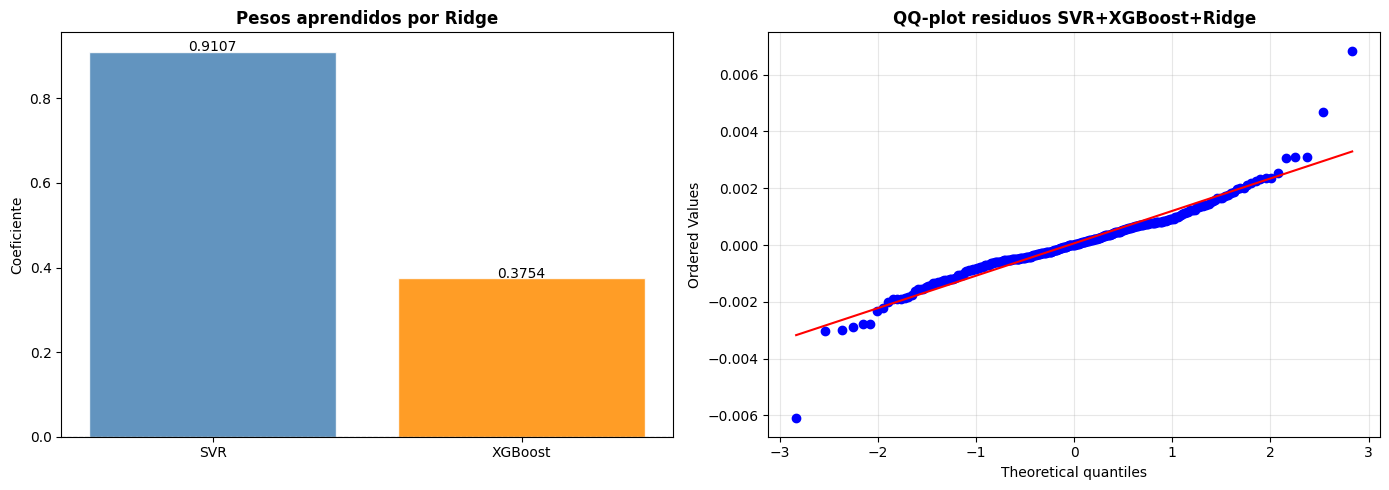

In [33]:
# ── Pesos del meta-modelo Ridge + QQ-plot ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pesos aprendidos por Ridge
modelos_nombres = ['SVR', 'XGBoost']
colores = ['steelblue', 'darkorange']
axes[0].bar(modelos_nombres, ridge_final.coef_, color=colores, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Pesos aprendidos por Ridge', fontweight='bold')
axes[0].set_ylabel('Coeficiente')
for i, v in enumerate(ridge_final.coef_):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

from scipy.stats import probplot
probplot(res_hybrid, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot residuos SVR+XGBoost+Ridge', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


La gráfica de pesos aprendidos por Ridge muestra que el modelo híbrido asignó una mayor importancia al SVR en comparación con XGBoost. El coeficiente de 0.9107 para SVR indica que este modelo aporta la mayor parte de la capacidad predictiva del ensamble, mientras que XGBoost contribuye de manera complementaria con un peso de 0.3754. Esto sugiere que las predicciones de SVR fueron más estables y consistentes durante el entrenamiento, aunque la inclusión de XGBoost permitió capturar patrones adicionales que ayudaron a mejorar ligeramente el rendimiento final del modelo híbrido.

Por otro lado, el QQ plot de los residuos evidencia que la mayor parte de los errores sigue aproximadamente una distribución cercana a la normal, especialmente en la zona central donde los puntos se alinean con la recta teórica. Sin embargo, en los extremos se observan desviaciones importantes, lo que indica la presencia de valores atípicos y colas pesadas. Este comportamiento es común en series financieras como Bitcoin debido a la alta volatilidad y a los movimientos bruscos del mercado. Aun así, el alineamiento general de los residuos alrededor de la recta sugiere que el modelo híbrido logra capturar adecuadamente gran parte de la dinámica de los retornos.

### Comparación con modelos benchmark

La comparación final entre los modelos benchmark y el modelo híbrido propuesto demuestra que la combinación SVR + XGBoost + Ridge obtuvo el mejor desempeño general en términos de error predictivo. Mientras que los modelos benchmark presentaron valores de RMSE entre 0.00270 y 0.00279, el modelo híbrido alcanzó un RMSE de 0.00259, logrando una mejora aproximada del 4.35% frente al mejor modelo individual, que fue SVR. De igual manera, el modelo híbrido obtuvo el menor MAE con un valor de 0.00158, indicando una reducción en el error absoluto promedio de las predicciones.

En cuanto a la métrica Direction Accuracy, los resultados muestran que la mayoría de modelos lograron superar el 50%, lo cual es relevante en un problema de predicción financiera de alta frecuencia como Bitcoin a intervalos de 15 minutos. Sin embargo, el modelo híbrido alcanzó el mejor desempeño con un DA de 0.576, superando ligeramente a SVR y Ridge. Esto indica una mayor capacidad para identificar correctamente la dirección de movimiento del mercado, incluso en un entorno altamente volátil y ruidoso.

En términos generales, los resultados evidencian que el modelo híbrido logra aprovechar las fortalezas complementarias de SVR y XGBoost mediante Ridge como meta modelo combinador. SVR aportó estabilidad y capacidad de generalización, mientras que XGBoost permitió capturar relaciones no lineales adicionales presentes en los datos. Como resultado, el ensamble consiguió predicciones más precisas y consistentes que las obtenidas por los modelos benchmark individuales, validando la efectividad del enfoque híbrido propuesto para la predicción de retornos del Bitcoin.